# Exploratory Data Analysis

This notebook explores the datasets used in the thesis before model training. It checks the sentiment dataset, the sarcasm dataset, the sarcasm-focused Golden Set, and the generated rationale data. 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import emoji
 
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from textblob import TextBlob
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

### EDA on Sentiment Dataset

In [2]:
# Load Sentiment Data
df_sent_train = pd.read_csv("../data/raw/sentiment_train.csv")
df_sent_val = pd.read_csv("../data/raw/sentiment_validation.csv")
df_sent_test = pd.read_csv("../data/raw/sentiment_test.csv")

print("Sentiment train:", df_sent_train.shape)
print("Sentiment val:", df_sent_val.shape)
print("Sentiment test:", df_sent_test.shape)
print(df_sent_train.info())
print(df_sent_train.head())

Sentiment train: (45615, 2)
Sentiment val: (2000, 2)
Sentiment test: (12284, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45615 entries, 0 to 45614
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    45615 non-null  object
 1   label   45615 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 712.9+ KB
None
                                                text  label
0  "QT @user In the original draft of the 7th boo...      2
1  "Ben Smith / Smith (concussion) remains out of...      1
2  Sorry bout the stream last night I crashed out...      1
3  Chase Headley's RBI double in the 8th inning o...      1
4  @user Alciato: Bee will invest 150 million in ...      2


In [74]:
print("Missing values:")
print(df_sent_train.isnull().sum())

print("\nDuplicates:")
print(df_sent_train['text'].duplicated().sum())

Missing values:
text     0
label    0
dtype: int64

Duplicates:
29


C:\Users\Anh Thu\AppData\Local\Temp\ipykernel_38644\4129264565.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df_sent_train, palette='viridis')


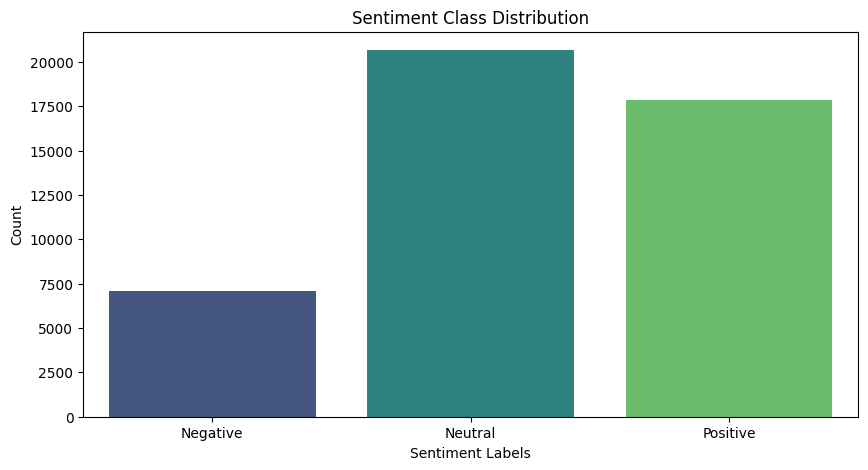

Percentage distribution of sentiment classes:
label
Neutral     0.453206
Positive    0.391297
Negative    0.155497
Name: proportion, dtype: float64


In [75]:
# Visualize Sentiment Class Distribution in the Training Set
plt.figure(figsize=(10, 5))
sns.countplot(x='label', data=df_sent_train, palette='viridis')
plt.xticks([0, 1, 2], ['Negative', 'Neutral', 'Positive'])
plt.xlabel('Sentiment Labels')
plt.ylabel('Count')
plt.title('Sentiment Class Distribution')
plt.show()
# Print percentage distribution of sentiment classes
print("Percentage distribution of sentiment classes:")
label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}
print(df_sent_train['label'].map(label_map).value_counts(normalize=True))


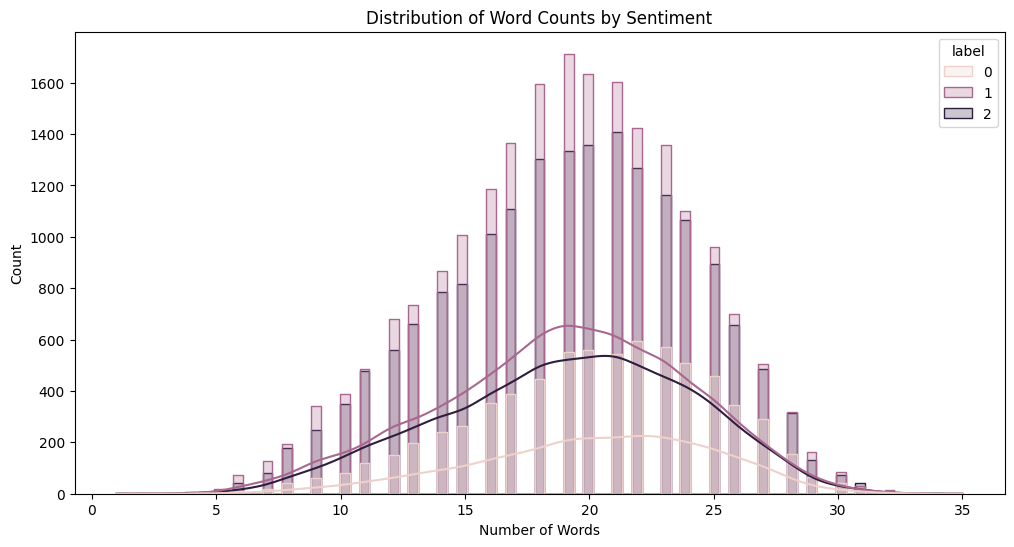

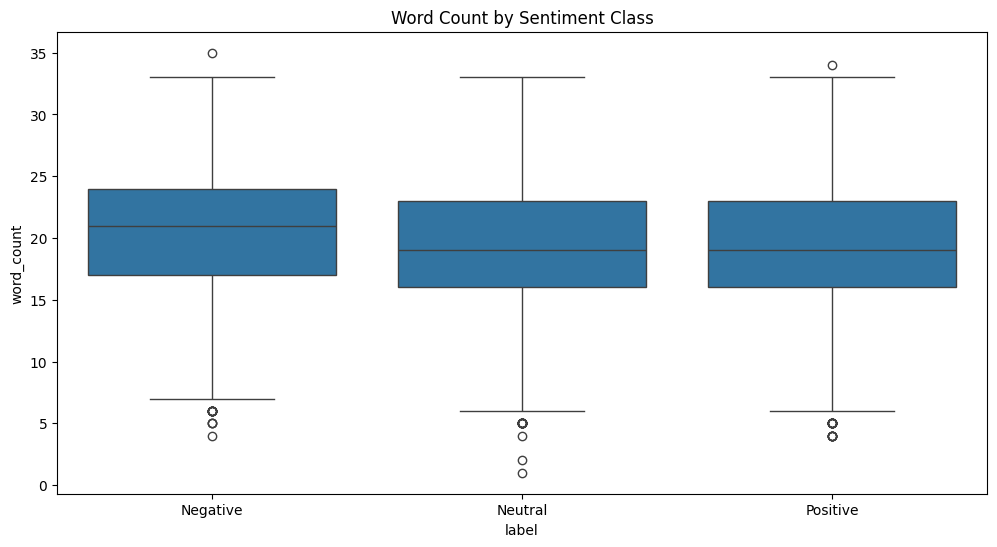

In [76]:
# Visualize Word Count Distribution by Sentiment Class
df_sent_train['char_length'] = df_sent_train['text'].apply(len)
df_sent_train['word_count'] = df_sent_train['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 6))
sns.histplot(data=df_sent_train, x='word_count', hue='label', kde=True, element="step")
plt.title('Distribution of Word Counts by Sentiment')
plt.xlabel('Number of Words')
plt.show()

# Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='label', y='word_count', data=df_sent_train)
plt.xticks([0, 1, 2], ['Negative', 'Neutral', 'Positive'])
plt.title("Word Count by Sentiment Class")
plt.show()

In [ ]:
def clean_for_eda(text):
    if not isinstance(text, str): return ""
    # Convert all 'uXXXX' hex codes to actual characters
    text = re.sub(r'u([0-9a-fA-F]{4})', lambda m: chr(int(m.group(1), 16)), text)
    # General Cleaning for EDA (Remove placeholders that bloat bigrams)
    text = text.lower()
    text = re.sub(r'@user|user|http\S+|http', '', text) # Remove @user, user, and urls
    # Standardize apostrophes (sometimes unicode conversion leaves varied types)
    text = re.sub(r"[\u2018\u2019\u201a\u201b]", "'", text)
    # Remove non-alphanumeric noise (keep spaces and apostrophes)
    text = re.sub(r"[^a-zA-Z'\s]", ' ', text)
    # Final squeeze (remove extra whitespace)
    return " ".join(text.split())

df_sent_train['clean_text'] = df_sent_train['text'].apply(clean_for_eda)

In [78]:
# Calculate lexicon sentiment for the Sentiment Dataset
df_sent_train['lexicon_polarity'] = df_sent_train['text'].apply(lambda x: TextBlob(x).sentiment.polarity)

# Identify "Contradictory" Negative Tweets (Label is Negative, but words are Positive)
contradictory_neg = df_sent_train[(df_sent_train['label'] == 0) & (df_sent_train['lexicon_polarity'] > 0.2)]
 
print(f"Number of 'Contradictory' Negative tweets: {len(contradictory_neg)}")
print(f"Percentage of Negative class that is likely sarcastic/confusing: {len(contradictory_neg)/len(df_sent_train[df_sent_train['label']==0])*100:.2f}%")
# Show examples of these "confusing" tweets
print("\nExamples of Negative tweets with Positive words:")
print(contradictory_neg[['text', 'lexicon_polarity']].head(5))
 

Number of 'Contradictory' Negative tweets: 1107
Percentage of Negative class that is likely sarcastic/confusing: 15.61%

Examples of Negative tweets with Positive words:
                                                  text  lexicon_polarity
59   Amazon prime is literally a lie....I ordered a...          0.250000
60   Who the hell moshes at Matt and Kim?? Next tim...          0.250000
66   Mario Williams is catching hell! He will be Ex...          0.937500
158  "Oomf is gay. He may not know it yet, but I do...          0.608333
164  Yes it is. Bori practitioners have survived by...          0.433333


C:\Users\Anh Thu\AppData\Local\Temp\ipykernel_38644\2864071862.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='label', y='lexicon_polarity', data=df_sent_train, palette='viridis')


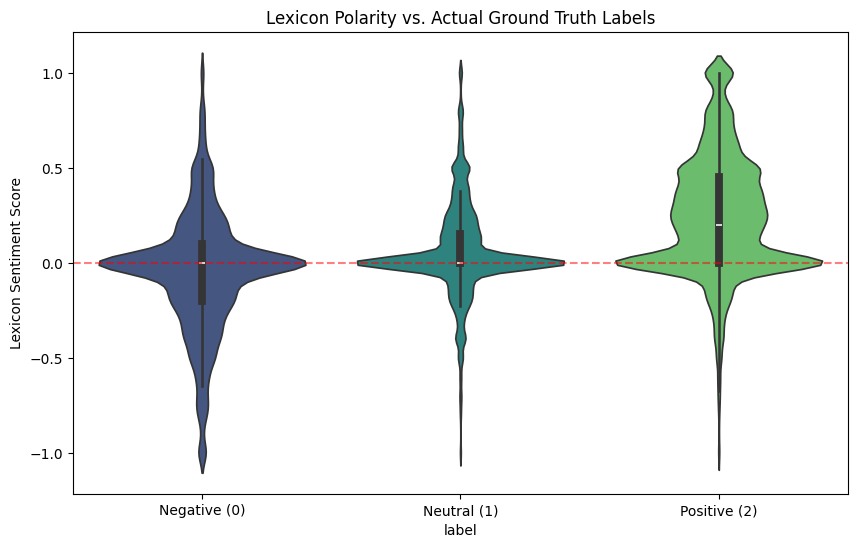

In [79]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='label', y='lexicon_polarity', data=df_sent_train, palette='viridis')
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.title('Lexicon Polarity vs. Actual Ground Truth Labels')
plt.xticks([0, 1, 2], ['Negative (0)', 'Neutral (1)', 'Positive (2)'])
plt.ylabel('Lexicon Sentiment Score')
plt.show()
 

In [80]:
# Look at negative tweets that have the highest POSITIVE lexicon scores
confusing_negatives = df_sent_train[(df_sent_train['label'] == 0)].sort_values(by='lexicon_polarity', ascending=False)

print("Top 20 'Negative' tweets that use 'Positive' words (Likely Sarcastic):")
for i, row in confusing_negatives.head(20).iterrows():
    print(f"- Score: {row['lexicon_polarity']:.2f} | Text: {row['text']}")

Top 20 'Negative' tweets that use 'Positive' words (Likely Sarcastic):
- Score: 1.00 | Text: @user take a pic with @user on Sunday PLZZZZZZZZZ!!!!!! The gays will die and go to gay glitter heaven!!!!
- Score: 1.00 | Text: i haven\u2019t worn Makeup since Ash Wed. ;o <3 i don\u2019t like it anymore .
- Score: 1.00 | Text: "How are these fools talking about \""Niners are the best team in the NFC\"".Last time i checked\u002c the Giants SHAT on them. Held them to FG in 4th"
- Score: 1.00 | Text: Now that Iran ripped us off by the legendary Watch this Friday.
- Score: 1.00 | Text: it's supposed to snow from midnight tonight until 6pm tomorrow? oh well that's friggin awesome"
- Score: 1.00 | Text: @user naww U2 may not be the best band for you then
- Score: 1.00 | Text: Sandy messed up the great feeling of the Redskins\u002c Cowboys\u002c an Eagles all losing on Sunday! #Giants
- Score: 1.00 | Text: @user @user now that Rick Perry is out of the the GOP race ... MAY THE BEST HAIR WIN!
- Score

In [5]:
# Golden Set Data Leakage Check
def load_golden_set(filepath):
    label_map = {"negative": 0, "neutral": 1, "positive": 2}
    data = []
    with open(filepath, "r") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) >= 3:
                data.append({"text": parts[2], "label": label_map[parts[1].lower()]})
    return pd.DataFrame(data)
 
df_golden = load_golden_set("../data/raw/twitter-2014sarcasm-A.txt")
 
print(f"Size: {len(df_golden)} tweets")
print(df_golden['label'].map({0: "Negative", 1: "Neutral", 2: "Positive"}).value_counts())

# Check overlapping tweets
leaked_train = df_sent_train[df_sent_train['text'].isin(df_golden['text'])]
leaked_val = df_sent_val[df_sent_val['text'].isin(df_golden['text'])]

print(f"\nLeaked tweets found in sentiment training data: {len(leaked_train)}")
print(f"\nLeaked tweets found in sentiment validation data: {len(leaked_val)}")


Size: 86 tweets
label
Negative    40
Positive    33
Neutral     13
Name: count, dtype: int64

Leaked tweets found in sentiment training data: 57

Leaked tweets found in sentiment validation data: 0


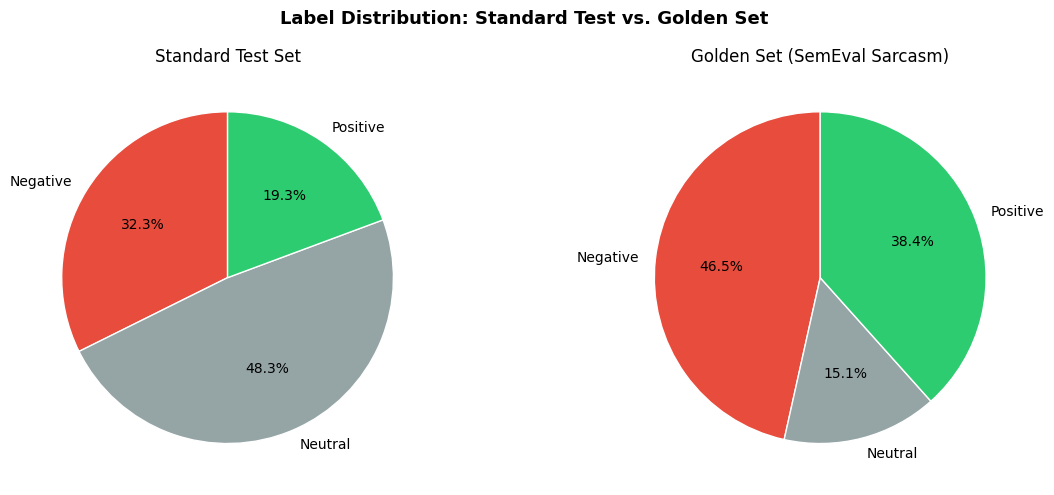

Negative class: Standard test 32.3%  |  Golden set 46.5%


In [82]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
for ax, df, title in zip(axes,
                          [df_sent_test, df_golden],
                          ["Standard Test Set", "Golden Set (SemEval Sarcasm)"]):
    counts = df['label'].value_counts().sort_index()
    label_names = [label_map[i] for i in counts.index]
    ax.pie(counts.values, labels=label_names, autopct="%1.1f%%",
           colors=["#e74c3c", "#95a5a6", "#2ecc71"][:len(counts)],
           startangle=90, wedgeprops=dict(edgecolor='white'))
    ax.set_title(title)
 
plt.suptitle("Label Distribution: Standard Test vs. Golden Set", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
 
gold_neg_pct = (df_golden['label'] == 0).mean() * 100
test_neg_pct = (df_sent_test['label'] == 0).mean() * 100
print(f"Negative class: Standard test {test_neg_pct:.1f}%  |  Golden set {gold_neg_pct:.1f}%")

 => The golden set is skewed toward negative/positive tweets, making it a good stress test for sarcasm robustness

### EDA on Sarcasm Data

In [92]:
# Load Sarcasm
df_isarc_train = pd.read_csv("../data/raw/iSarcasm_Train.csv")
df_isarc_train = df_isarc_train[["tweet", "sarcastic"]].rename(
    columns={"tweet": "text", "sarcastic": "label"}
)
df_isarc_test = pd.read_csv("../data/raw/iSarcasm_Test.csv")
df_isarc_test = df_isarc_test[["text", "sarcastic"]].rename(
    columns={"sarcastic": "label"}
)

# Combine all Sarcasm sources
df_sarc = pd.concat([df_isarc_train, df_isarc_test], ignore_index=True)

# Remove nulls and duplicates
df_sarc = df_sarc.dropna(subset=["text"]).drop_duplicates(subset=["text"])
df_sarc["text"] = df_sarc["text"].astype(str)

# Map label
label_map = {0: "Non-Sarcastic", 1: "Sarcastic"}
df_sarc['label'] = df_sarc['label'].map(label_map)

print("Sarcasm train:", df_sarc.shape)
print(df_sarc.info())
print(df_sarc.head())


Sarcasm train: (4850, 2)
<class 'pandas.core.frame.DataFrame'>
Index: 4850 entries, 0 to 4867
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    4850 non-null   object
 1   label   4850 non-null   object
dtypes: object(2)
memory usage: 113.7+ KB
None
                                                text      label
0  The only thing I got from college is a caffein...  Sarcastic
1  I love it when professors draw a big question ...  Sarcastic
2  Remember the hundred emails from companies whe...  Sarcastic
3  Today my pop-pop told me I was not “forced” to...  Sarcastic
4  @VolphanCarol @littlewhitty @mysticalmanatee I...  Sarcastic


In [93]:
def preprocess_sarc(text):
    text = re.sub(r"@[^\s]+", "@user", text)
    text = re.sub(r"http\S+", "http", text)
    text = " ".join(text.split())
    text = emoji.demojize(text, delimiters=(" :", ": "))
    return text

df_sarc['text'] = df_sarc['text'].apply(preprocess_sarc)

C:\Users\Anh Thu\AppData\Local\Temp\ipykernel_38644\3969623058.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df_sarc, palette='viridis')


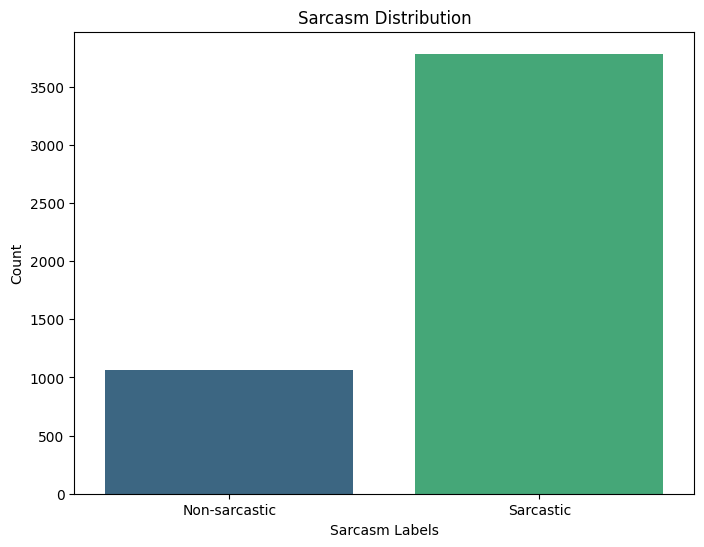

Percentage distribution of sarcasm classes:
label
Non-Sarcastic    0.78
Sarcastic        0.22
Name: proportion, dtype: float64


In [94]:
# Visualize Sarcastic Distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='label', data=df_sarc, palette='viridis')
plt.xticks([0, 1], ['Non-sarcastic', 'Sarcastic'])
plt.xlabel('Sarcasm Labels')
plt.ylabel('Count')
plt.title("Sarcasm Distribution")
plt.show()

# Print percentage distribution of sarcastic classes
print("Percentage distribution of sarcasm classes:")
print(df_sarc['label'].value_counts(normalize=True))

In [95]:
def clean_for_sarcasm_eda(text):
    text = text.lower()
    text = re.sub(r'@user|http', '', text)
    text = re.sub(r"[^a-zA-Z0-9'?!.\s]", ' ', text)
    return " ".join(text.split())

df_sarc['clean_text'] = df_sarc['text'].apply(clean_for_sarcasm_eda)

def get_top_bigrams_sarcasm(corpus, n_top=10):
    vec = CountVectorizer(
        ngram_range=(2,2),
        stop_words='english'
    ).fit(corpus)

    bag = vec.transform(corpus)
    sums = bag.sum(axis=0)

    words_freq = [
        (word, sums[0, idx])
        for word, idx in vec.vocabulary_.items()
    ]

    return sorted(words_freq, key=lambda x:x[1], reverse=True)[:n_top]

print("Non-sarcastic:")
print(get_top_bigrams_sarcasm(
    df_sarc[df_sarc['label']=="Non-Sarcastic"]['clean_text']
))

print("Sarcastic:")
print(get_top_bigrams_sarcasm(
    df_sarc[df_sarc['label']=="Sarcastic"]['clean_text']
))

Non-sarcastic:
[('smiling face', np.int64(98)), ('skin tone', np.int64(86)), ('crying face', np.int64(84)), ('loudly crying', np.int64(76)), ('light skin', np.int64(68)), ('face tears', np.int64(67)), ('tears joy', np.int64(67)), ('red heart', np.int64(56)), ('face heart', np.int64(46)), ('heart eyes', np.int64(44))]
Sarcastic:
[('smiling face', np.int64(40)), ('skin tone', np.int64(26)), ('upside face', np.int64(25)), ('face rolling', np.int64(22)), ('rolling eyes', np.int64(22)), ('light skin', np.int64(21)), ('face tears', np.int64(14)), ('tears joy', np.int64(14)), ('weary face', np.int64(14)), ('face hearts', np.int64(12))]


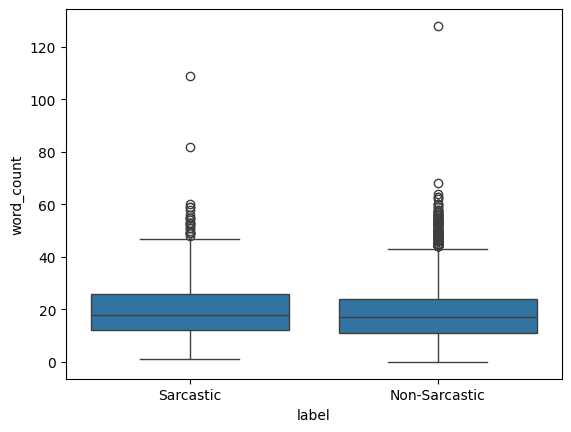

In [96]:
df_sarc['word_count'] = df_sarc['clean_text'].apply(lambda x: len(x.split()))

sns.boxplot(x='label', y='word_count', data=df_sarc)
plt.show()

In [97]:
markers = ['!', '?', '...']

for m in markers:
    df_sarc[m] = df_sarc['text'].str.count(re.escape(m))

df_sarc.groupby('label')[markers].mean()

,!,?,...
label,,,
Non-Sarcastic,0.201956,0.137193,0.038329
Sarcastic,0.256795,0.227741,0.060918


C:\Users\Anh Thu\AppData\Local\Temp\ipykernel_38644\3577445180.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='label', y='punc_count', data=df_sarc_style, ax=ax[0], palette='magma')
C:\Users\Anh Thu\AppData\Local\Temp\ipykernel_38644\3577445180.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='label', y='caps_ratio', data=df_sarc_style, ax=ax[1], palette='magma')


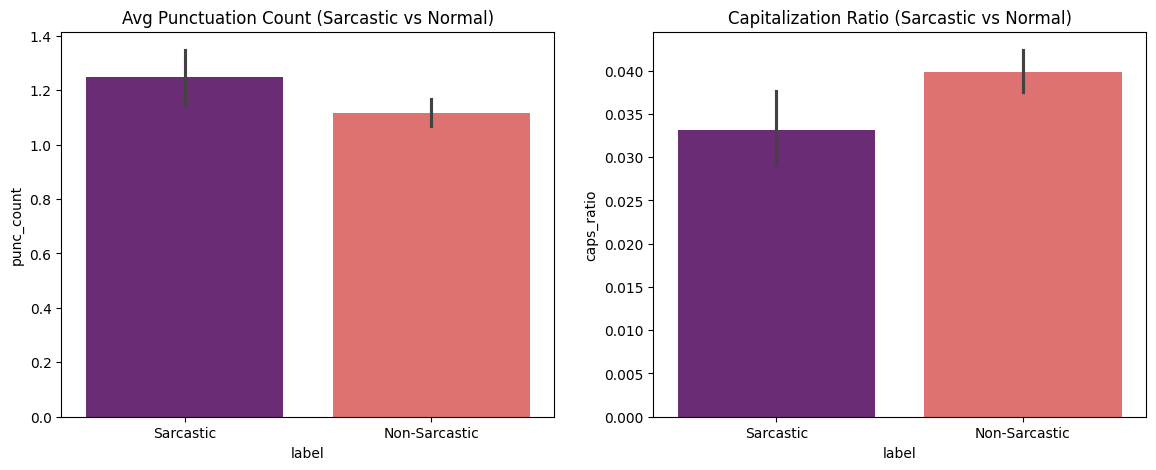

In [ ]:
## Intensity and Stylometric Analysis
def get_stylometrics(df):
    df = df.copy()
    # Punctuation density
    df['punc_count'] = df['text'].apply(lambda x: len(re.findall(r'[!?.]', x)))
    # Capitalization ratio (often used in sarcasm)
    df['caps_ratio'] = df['text'].apply(lambda x: sum(1 for c in x if c.isupper()) / (len(x)+1))
    return df

df_sarc_style = get_stylometrics(df_sarc)

# Plotting the difference
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x='label', y='punc_count', data=df_sarc_style, ax=ax[0], palette='magma')
ax[0].set_title('Avg Punctuation Count (Sarcastic vs Normal)')

sns.barplot(x='label', y='caps_ratio', data=df_sarc_style, ax=ax[1], palette='magma')
ax[1].set_title('Capitalization Ratio (Sarcastic vs Normal)')
plt.show()

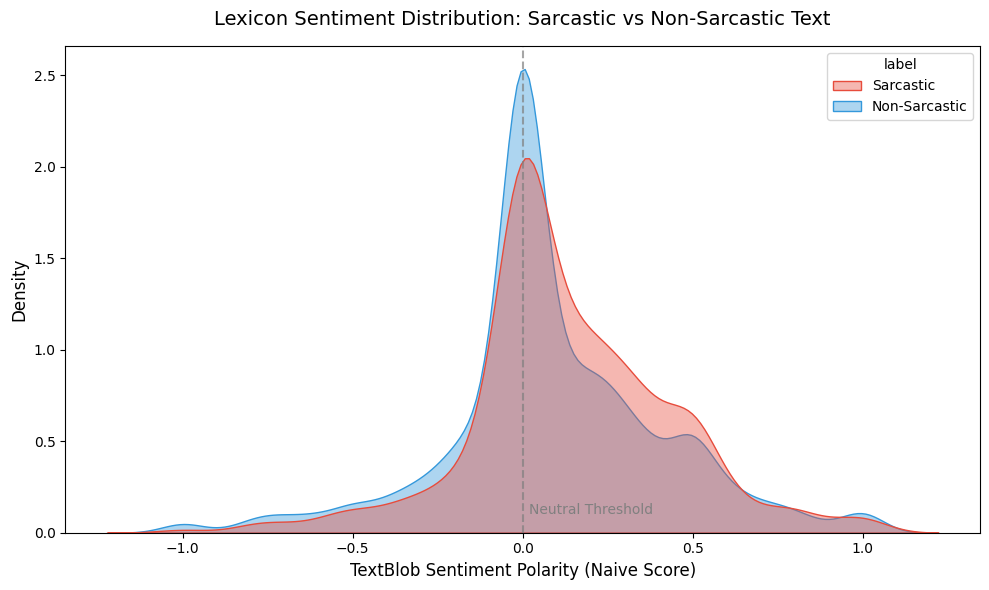

In [103]:
## Check lexicon sentiment score in 2 classes
# Calculate lexicon sentiment with TextBlob
df_sarc['lexicon_sentiment'] = df_sarc['text'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

# Plot
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df_sarc, 
    x='lexicon_sentiment', 
    hue='label', 
    fill=True, 
    common_norm=False,  
    palette={'Sarcastic': '#e74c3c', 'Non-Sarcastic': '#3498db'},
    alpha=0.4
)
plt.title('Lexicon Sentiment Distribution: Sarcastic vs Non-Sarcastic Text', fontsize=14, pad=15)
plt.xlabel('TextBlob Sentiment Polarity (Naive Score)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.axvline(0, color='grey', linestyle='--', alpha=0.7)
plt.text(0.02, 0.1, 'Neutral Threshold', color='grey', fontsize=10)
plt.tight_layout()
plt.show()

=> The orange (sarcastic) range is skewed to the positive side -> sarcastic tweets are likely to have positive sentiment score -> confuse the model

In [104]:
# Quantify the confusion
sarc_but_positive_surface = df_sarc[(df_sarc['label'] == "Sarcastic") & (df_sarc['lexicon_sentiment'] > 0.1)]
sarc_total = (df_sarc['label'] == "Sarcastic").sum()
print(f"\nSarcastic tweets with positive surface polarity (polarity > 0.1): "
      f"{len(sarc_but_positive_surface)} / {sarc_total} = {len(sarc_but_positive_surface)/sarc_total*100:.1f}%")


Sarcastic tweets with positive surface polarity (polarity > 0.1): 498 / 1067 = 46.7%


In [105]:
# Vocabulary Overlap Between Sentiment and Sarcasm Datasets
def get_top_vocab(series, n=1000):
    cleaned = series.apply(lambda x: re.sub(r'@\S+|http\S+', ' ', str(x).lower()))
    vec = CountVectorizer(stop_words='english', max_features=n)
    vec.fit(cleaned)
    return set(vec.get_feature_names_out())
 
sent_vocab = get_top_vocab(df_sent_train['text'], n=1000)
sarc_vocab = get_top_vocab(df_sarc['text'], n=1000)
 
overlap = sent_vocab & sarc_vocab
sent_only = sent_vocab - sarc_vocab
sarc_only = sarc_vocab - sent_vocab
 
print(f"\nVocabulary Overlap (Top-1000 tokens each)")
print(f"Shared        : {len(overlap)} tokens ({len(overlap)/10:.0f}%)")
print(f"Sentiment only: {len(sent_only)} tokens")
print(f"Sarcasm only  : {len(sarc_only)} tokens")
 


Vocabulary Overlap (Top-1000 tokens each)
Shared        : 536 tokens (54%)
Sentiment only: 464 tokens
Sarcasm only  : 464 tokens


=> High overlap (more than half) -> 2 dataset are strongly related linguistically -> using the shared RoBERTa backbone is suitable

### Rationale Analysis

In [106]:
# Load rationale dataset
df_sent_rat = pd.read_csv("../data/processed/sentiment_train_with_rationales.csv")
df_sarc_rat = pd.read_csv("../data/processed/sarcasm_train_with_rationales.csv")
# Clean data
df_sent_rat['text'] = df_sent_rat['text'].astype(str)
df_sent_rat['rationale'] = df_sent_rat['rationale'].astype(str)

df_sarc_rat['text'] = df_sarc_rat['text'].astype(str)
df_sarc_rat['rationale'] = df_sarc_rat['rationale'].astype(str)
# Check missing rationales
print("Number of missing rationales (Sentiment):", df_sent_rat['rationale'].isnull().sum())
print("Number of missing rationales (Sarcasm)", df_sarc_rat['rationale'].isnull().sum())

Number of missing rationales (Sentiment): 0
Number of missing rationales (Sarcasm) 0


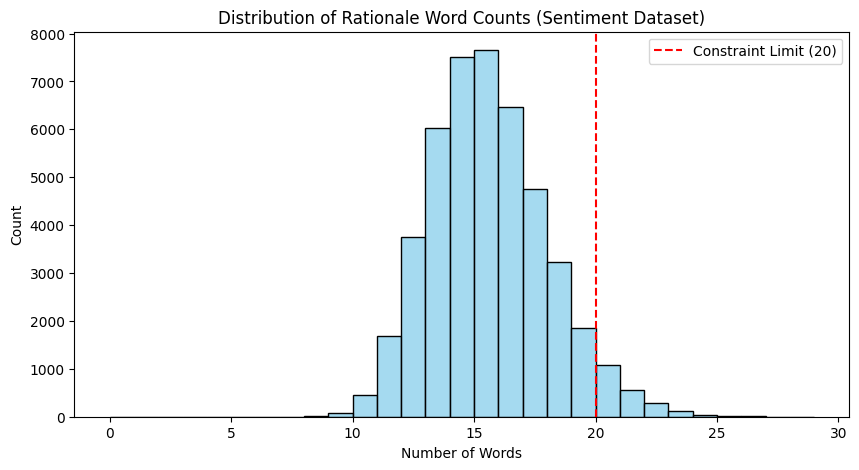

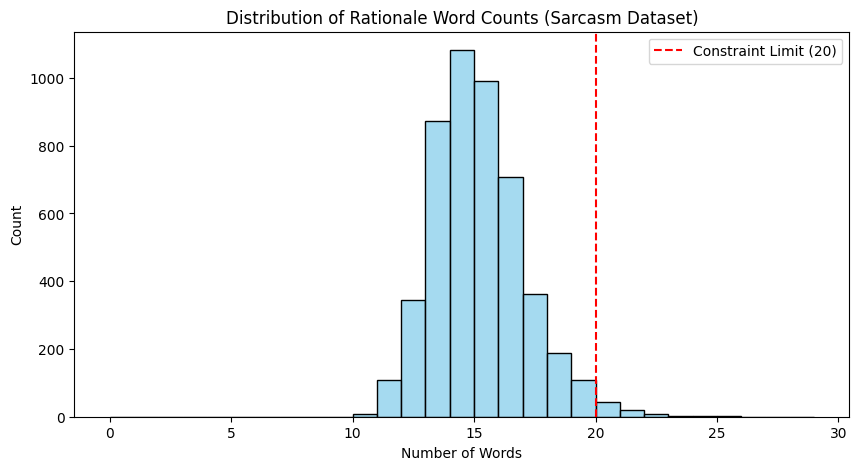

In [107]:
# Rationale Length Distribution
df_sent_rat['rat_word_count'] = df_sent_rat['rationale'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
sns.histplot(df_sent_rat['rat_word_count'], bins=range(0, 30), kde=False, color='skyblue')
plt.axvline(20, color='red', linestyle='--', label='Constraint Limit (20)')
plt.title('Distribution of Rationale Word Counts (Sentiment Dataset)')
plt.xlabel('Number of Words')
plt.legend()
plt.show()

df_sarc_rat['rat_word_count'] = df_sarc_rat['rationale'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
sns.histplot(df_sarc_rat['rat_word_count'], bins=range(0, 30), kde=False, color='skyblue')
plt.axvline(20, color='red', linestyle='--', label='Constraint Limit (20)')
plt.title('Distribution of Rationale Word Counts (Sarcasm Dataset)')
plt.xlabel('Number of Words')
plt.legend()
plt.show()


In [108]:
# Label Word Leakage Audit 
sent_keywords = ['positive', 'negative', 'neutral']
sarc_keywords = ['sarcastic', 'non-sarcastic']

def get_leaks(text, keywords):
    text = str(text).lower()
    found = [word for word in keywords if word in text]
    return found if found else None

df_sent_rat['leaked_words'] = df_sent_rat['rationale'].apply(lambda x: get_leaks(x, sent_keywords))
df_sarc_rat['leaked_words'] = df_sarc_rat['rationale'].apply(lambda x: get_leaks(x, sarc_keywords))

print(f"SENTIMENT: {df_sent_rat['leaked_words'].notnull().sum()} leaks found.")
print(f"SARCASM:   {df_sarc_rat['leaked_words'].notnull().sum()} leaks found.")

SENTIMENT: 9355 leaks found.
SARCASM:   27 leaks found.


In [109]:
# Check if the rationale quote specific word in the tweet
df_sent_rat['has_quotes'] = df_sent_rat['rationale'].apply(lambda x: bool(re.search(r"['\"].*?['\"]", str(x))))
quote_rate_sent = df_sent_rat['has_quotes'].mean() * 100
print(f"{quote_rate_sent:.2f}% of sentiment rationales contain quoted lexical evidence.")

99.98% of sentiment rationales contain quoted lexical evidence.


In [110]:
# Check if sarcasm rationales use keyword that indicates the conflict/reverse
conflict_keywords = ['mismatch', 'irony', 'literal', 'intended', 'contrast', 'contradict']

if 'label' in df_sarc_rat.columns:
    df_sarc_rat = df_sarc_rat[df_sarc_rat['label'] == 1] 
    if not df_sarc_rat.empty:
        has_conflict_word = df_sarc_rat['rationale'].apply(
            lambda x: any(word in str(x).lower() for word in conflict_keywords)
        ).mean() * 100
        print(f"{has_conflict_word:.2f}% of sarcastic rationales use conflict keywords.")

66.54% of sarcastic rationales use conflict keywords.


In [ ]:
# Load embedding model
embed_model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate embeddings for both text and rationale
text_embs = embed_model.encode(df_sent_rat['text'].tolist())
rat_embs = embed_model.encode(df_sent_rat['rationale'].tolist())

# Calculate the row-wise similarity
sim_scores = [cosine_similarity([text_embs[i]], [rat_embs[i]])[0][0] for i in range(len(df_sent_rat))]
df_sent_rat['info_sim'] = sim_scores

print(f"Average Semantic Similarity: {df_sent_rat['info_sim'].mean():.3f}")

# Generate embeddings for Sarcasm rationale pairs
sarc_text_embs = embed_model.encode(df_sarc_rat['text'].tolist())
sarc_rat_embs = embed_model.encode(df_sarc_rat['rationale'].tolist())

# Calculate row-wise similarity
sarc_sim_scores = [cosine_similarity([sarc_text_embs[i]], [sarc_rat_embs[i]])[0][0] for i in range(len(df_sarc_rat))]
df_sarc_rat['info_sim'] = sarc_sim_scores

print(f"Average Sarcasm Rationale Similarity: {df_sarc_rat['info_sim'].mean():.3f}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Average Semantic Similarity: 0.450
Average Sarcasm Rationale Similarity: 0.487


In [113]:

# Initialize TF-IDF to find the most "important" reasoning words
tfidf = TfidfVectorizer(stop_words='english', max_features=100)
tfidf_matrix = tfidf.fit_transform(df_sent_rat['rationale'])

# Get the top words based on their total score across the dataset
importance = np.asarray(tfidf_matrix.sum(axis=0)).flatten()
word_names = tfidf.get_feature_names_out()
top_words = [word_names[i] for i in importance.argsort()[-15:][::-1]]

print("Top 15 Reasoning Keywords used in Rationales:")
print(top_words)

Top 15 Reasoning Keywords used in Rationales:
['words', 'emotional', 'phrase', 'factual', 'provide', 'modifiers', 'conveys', 'reporting', 'information', 'excitement', 'strong', 'indicates', 'positive', 'indicate', 'sentiment']
